In [121]:
import os
import pandas as pd
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'/Users/ryan/github/prosodic')
# !pip install -r /Users/ryan/github/prosodic/requirements.txt

import prosodic
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100
from tqdm.auto import tqdm

import plotnine as p9
import numpy as np

constraints={
    'w_peak':1,
    'w_stress':1,
    's_unstress':1,
    'unres_across':1,
    'unres_within':1,
    # 'pentameter':1000,
    # 'iambic':1000,
}

meter = prosodic.Meter(
    constraints=constraints,
    resolve_optionality=True,
    max_s=1,
    max_w=2,
)

def find_feet_in_meter_str(meter_str):
    feet = []
    foot = []
    def has_strong(wss):
        return any(ws in {'s','+'} for ws in wss)

    for ws in meter_str:
        foot.append(ws)
        if len(foot)>1 and (has_strong(foot) or ws in {'s','+'}):
            feet.append(foot)
            foot = []
    return [''.join(f) for f in feet]

find_feet_in_meter_str('--+-+-+-+')

def find_pos_in_meter_str(meter_str):
    pos=''
    posl=[]
    for ws in meter_str:
        if pos and ws!=pos[-1]:
            posl.append(pos)
            pos=''
        pos+=ws
    if pos: posl.append(pos)
    return posl

find_pos_in_meter_str('--+-+-+-+')

def is_binary_meter(meter_str):
    feet = find_feet_in_meter_str(meter_str)
    return max(set(len(f) for f in feet), key=list(len(f) for f in feet).count) == 2

def is_iambic_meter(meter_str):
    return meter_str[3]=='+' and is_binary_meter(meter_str)

def is_iambic_pentameter(meter_str):
    return is_iambic_meter(meter_str) and len(find_feet_in_meter_str(meter_str))==5

assert is_iambic_pentameter('-+'*5 + '-')
assert is_iambic_pentameter('-+'*5)
assert is_iambic_pentameter('+--+-+-+-+')

#, is_iambic_pentameter('-+-+-+-+-+'), is_iambic_pentameter('-+-+-+-+-+-'), is_iambic_pentameter('-+-+-+-+-+--')



In [123]:
@prosodic.cache
def get_df_sonnets(sample_size=154):

    df=pd.read_pickle('data.allpoems.pkl')

    def filter_poem_txt(txt):
        vparas = [para.strip() for para in txt.split('\n\n') if '\n' in para.strip()]
        return '\n\n'.join(vparas)

    def num_lines_txt(txt):
        return len([v for v in txt.splitlines() if v.strip()])

    df['poem_txt'] = df['poem'].apply(filter_poem_txt)
    df['num_lines_txt'] = df['poem_txt'].apply(num_lines_txt)

    df['prompt'] = df['prompt'].fillna('')

    df_sonnets = df[
        df.prompt.str.contains('sonnet', case=False, na=False) |
        df.attgenre.str.contains('sonnet', case=False, na=False)
    ]

    # df_sonnets = df[df.prompt.str.contains('sonnet') | (df.prompt == '')]
    df_sonnets = df_sonnets[df_sonnets.num_lines==14]
    # df_sonnets.model.value_counts()
    # list(df_sonnets.columns)

    shaksonnets = prosodic.Text(fn='/Users/ryan/github/prosodic/corpora/corppoetry_en/en.shakespeare.txt')
    ld_shak = []
    for stanza in shaksonnets.stanzas:
        d = {'model':'shakespeare', 'poem_txt':stanza.txt.strip(), 'num_lines_txt':len(stanza.lines)}
        ld_shak.append(d)

    df_shak = pd.DataFrame(ld_shak)
    df_shak['poem'] = df_shak['poem_txt']
    df_shak['num_lines'] = df_shak['num_lines_txt']

    df_markov = pd.read_pickle('data.markov_sonnets.pkl')

    df_sonnets2 = pd.concat([df_sonnets, df_shak, df_markov])


    def get_agent(model):
        if model == 'shakespeare':
            return 'Shakes'
        elif model.startswith('b.'):
            cents = int(model[3:5])+1
            if cents in {17,18,19}:
                return 'C17-19'
            else:
                return f'C{cents}'
        elif 'markov' in model.lower():
            # return 'Markov'
            return model
        else:
            return 'LLM'


    df_sonnets2['agent'] = df_sonnets2['model'].apply(get_agent)
    df_sonnets2 = df_sonnets2[df_sonnets2.agent.notna()]

    # df_sonnets2 = pd.conca
    # df_sonnets2

    if sample_size is not None:
        df_sonnets_smpl = pd.concat(gdf.iloc[:sample_size] for _,gdf in df_sonnets2.groupby('agent'))
    else:
        df_sonnets_smpl = df_sonnets2
    return df_sonnets_smpl


In [124]:
# df_sonnets_smpl = get_df_sonnets()
# # df_sonnets_smpl.agent.value_counts()

In [154]:
def get_flex_parses_df(force=False):
    parses = []
    parse_dfs = []
    df_sonnets_smpl = get_df_sonnets()
    fn='data.sonnet_parses_iambic_pentameter_flex.pkl'
    if not force and os.path.exists(fn):
        parses_df = pd.read_pickle(fn)
    else:
        parse_stash = prosodic.HashStash('sonnet_parses_iambic_pentameter_flex3', serializer='pickle', engine='lmdb')
        # parse_stash.clear()


        parse_dfs = []
        for stanza_i,(i,row) in enumerate(tqdm(list(df_sonnets_smpl[['poem_txt','model','agent']].iterrows()), desc='Parsing sonnets')):
            try:
                stanza = prosodic.Text(txt=row.poem_txt)
            except Exception as e:
                print(e)
                continue
            for line_i,line in enumerate(stanza.lines):
                try:
                    # if line.wordforms_first.num_sylls != 10: continue
                    line_txt = line.txt.strip()
                    parse_df = parse_stash.get(line_txt)
                    if parse_df is None:
                        parses = line.parse(meter=meter,num_proc=1)
                        parse = parses.best_parse
                        parse_df = parse.df.reset_index().assign(**parse.prefix_attrs)
                        parse_stash.set(line_txt, parse_df)
                    
                    # parse_df = parse_df.copy()  # Create a copy
                    # if 'line_num' in parse_df.index.names:
                    #     parse_df = parse_df.reset_index(level='line_num')
                    # else:
                    #     parse_df = parse_df.reset_index()
                        
                    # parse_df['stanza_num'] = stanza_i+1
                    # parse_df['line_num2'] = line_i+1
                    parse_df = parse_df.assign(
                        agent = row.agent,
                        model = row.model, 
                        stanza_num=stanza_i+1, 
                        line_num=line_i+1
                    )
                    parse_dfs.append(parse_df)
                except Exception as e:
                    print('!!',e)
                    continue

        parses_df = pd.concat(parse_dfs)
        parses_df.to_pickle(fn)

    parses_df = pd.concat(gdf for g,gdf in parses_df.groupby(['stanza_num']) if gdf.line_num.nunique() >= 5)
    # parses_df['agent'] = parses_df['model'].apply(get_agent)

    parses_df['*total'] = parses_df[[c for c in parses_df.columns if c[0]=='*']].sum(axis=1)
    parses_df['parse_num_sylls'] = parses_df['parse_meter'].apply(lambda x: len(x))
    return parses_df.query('10<=parse_num_sylls<=12')


In [155]:
# flex_parses_df = get_flex_parses_df(force=True)
flex_parses_df = get_flex_parses_df(force=False)
# flex_parses_df

In [156]:
# dict(flex_parses_df.iloc[0])

In [163]:


def plot_trochaic_substitutions(metric='has_trochaic_substitution'):
    figdf = get_flex_parses_df(force=False)
    figdf = figdf.drop_duplicates(['stanza_num','line_num'])
    figdf['has_trochaic_substitution'] = figdf['parse_meter'].apply(lambda x: x.startswith('+--+')).astype(int) * 100
    figdf['has_no_violations'] = (figdf['parse_num_viols'] == 0).astype(int) * 100
    figdf['unambiguous_parse'] = (figdf['parse_ambig'] == 1).astype(int) * 100
    
    # def is_iambic_pentameter(meter_str):
    #     return meter_str in {'-+-+-+-+-+', '-+-+-+-+-+-', '-+-+-+-+-+--'}
    
    figdf['is_iambic_pentameter'] = figdf['parse_meter'].apply(is_iambic_pentameter).astype(int) * 100
    figdf['is_unambiguously_iambic_pentameter'] = [100 if x and y else 0 for x,y in zip(figdf['is_iambic_pentameter'], figdf['unambiguous_parse'])]
    figdf['is_perfect_iambic_pentameter'] = [100 if x and y else 0 for x,y in zip(figdf['is_iambic_pentameter'], figdf['has_no_violations'])]
    figdf['is_unambiguously_perfect_iambic_pentameter'] = [100 if x and y and z else 0 for x,y,z in zip(figdf['is_iambic_pentameter'], figdf['unambiguous_parse'], figdf['has_no_violations'])]

    def get_agent(model):
        if model == 'shakespeare':
            return 'Shakespeare\'s sonnets'
        elif model.startswith('b.'):
            # return None
            cents = int(model[3:5])+1
            return f'C{cents} sonnets' if cents>19 else 'C17-19 sonnets'
        elif 'markov' in model.lower():
            return 'Markov model of\nShakespeare\'s sonnets' if 'shakespeare' in model.lower() else None# 'Markov model of C17-C20 sonnets'
        else:
            return 'LLM imitations of\nShakespeare\'s sonnets'

    figdf['agent'] = figdf['model'].apply(get_agent)
    figdf = figdf[~figdf['agent'].isna()]
    # figdf = figdf[['agent','has_trochaic_substitution','stanza_num']].groupby(['agent','stanza_num']).mean().reset_index()
    # figdf = pd.concat(gdf for g,gdf in figdf.groupby('stanza_num') if len(gdf)>=10)
    # figdf = figdf[['agent','stanza_num','has_trochaic_substitution']].groupby(['agent','stanza_num']).mean(numeric_only=True).reset_index()

    figdf = figdf.groupby('agent').agg({metric:['mean','std','count']}).reset_index()
    figdf.columns = ['agent','mean', 'std', 'count']

    p9.options.figure_size = (8, 6)
    # figdf['agent'] = pd.Categorical(figdf['agent'])
    
    figdf['value'] = figdf['mean']
    figdf['se'] = figdf['std'] / np.sqrt(figdf['count'])
    figdf['upper'] = figdf['mean'] + figdf['se']
    figdf['lower'] = figdf['mean'] - figdf['se']
    # figdf['mean'] = figdf['has_trochaic_substitution']
    figdf['label'] = [f'{round(xmean,1)}%' for xmean,xstd in zip(figdf['mean'], figdf['se'])]
    figdf['agent'] = [f'{xagent} (n={xcount:,})' for xagent,xcount in zip(figdf['agent'], figdf['count'])]    
    figdf['agent'] = pd.Categorical(figdf['agent'], categories=figdf.sort_values('mean',ascending=False).agent.unique())

    fig = p9.ggplot(figdf, p9.aes(x='agent', y='mean', label='label'))
    # fig+= p9.geom_boxplot()
    fig += p9.geom_errorbar(p9.aes(ymin='lower', ymax='upper'), data=figdf, width=.2, size=1, alpha=.5)
    fig+=p9.geom_point()
    fig+=p9.geom_text(size=9, position=p9.position_nudge(x=.2))
    fig+= p9.coord_flip()
    fig+=p9.theme_minimal()
    if metric == 'has_trochaic_substitution':
        fig+=p9.labs(
            y='% lines with trochaic substitution',
            x='Sonnet source',
            title='Likelihood of trochaic substitution in lines from sonnets'
        )
    elif metric == 'has_no_violations':
        fig+=p9.labs(
            y='% lines with no violations',
            x='Sonnet source',
            title='% Lines with perfect stress-meter alignment'
        )
    elif 'iambic_pentameter' in metric:
        fig+=p9.labs(
            y=f'% 10-12 syllable lines{" unambiguously" if metric=="is_unambiguously_iambic_pentameter" else " most easily"} parsed as iambic pentameter',
            x='Sonnet source',
            title='''Inhumanly strict metrical observance of iambic pentameter\nin LLM sonnets'''
        )
    fig+=p9.scale_y_continuous(limits=(0,100))
    fig.save(f'../../generative-humanities/Figures/{metric}.png')
    return fig


# plot_trochaic_substitutions()

In [161]:
# plot_trochaic_substitutions(metric='unambiguous_parse')
# plot_trochaic_substitutions(metric='has_no_violations')
# plot_trochaic_substitutions(metric='is_iambic_pentameter')

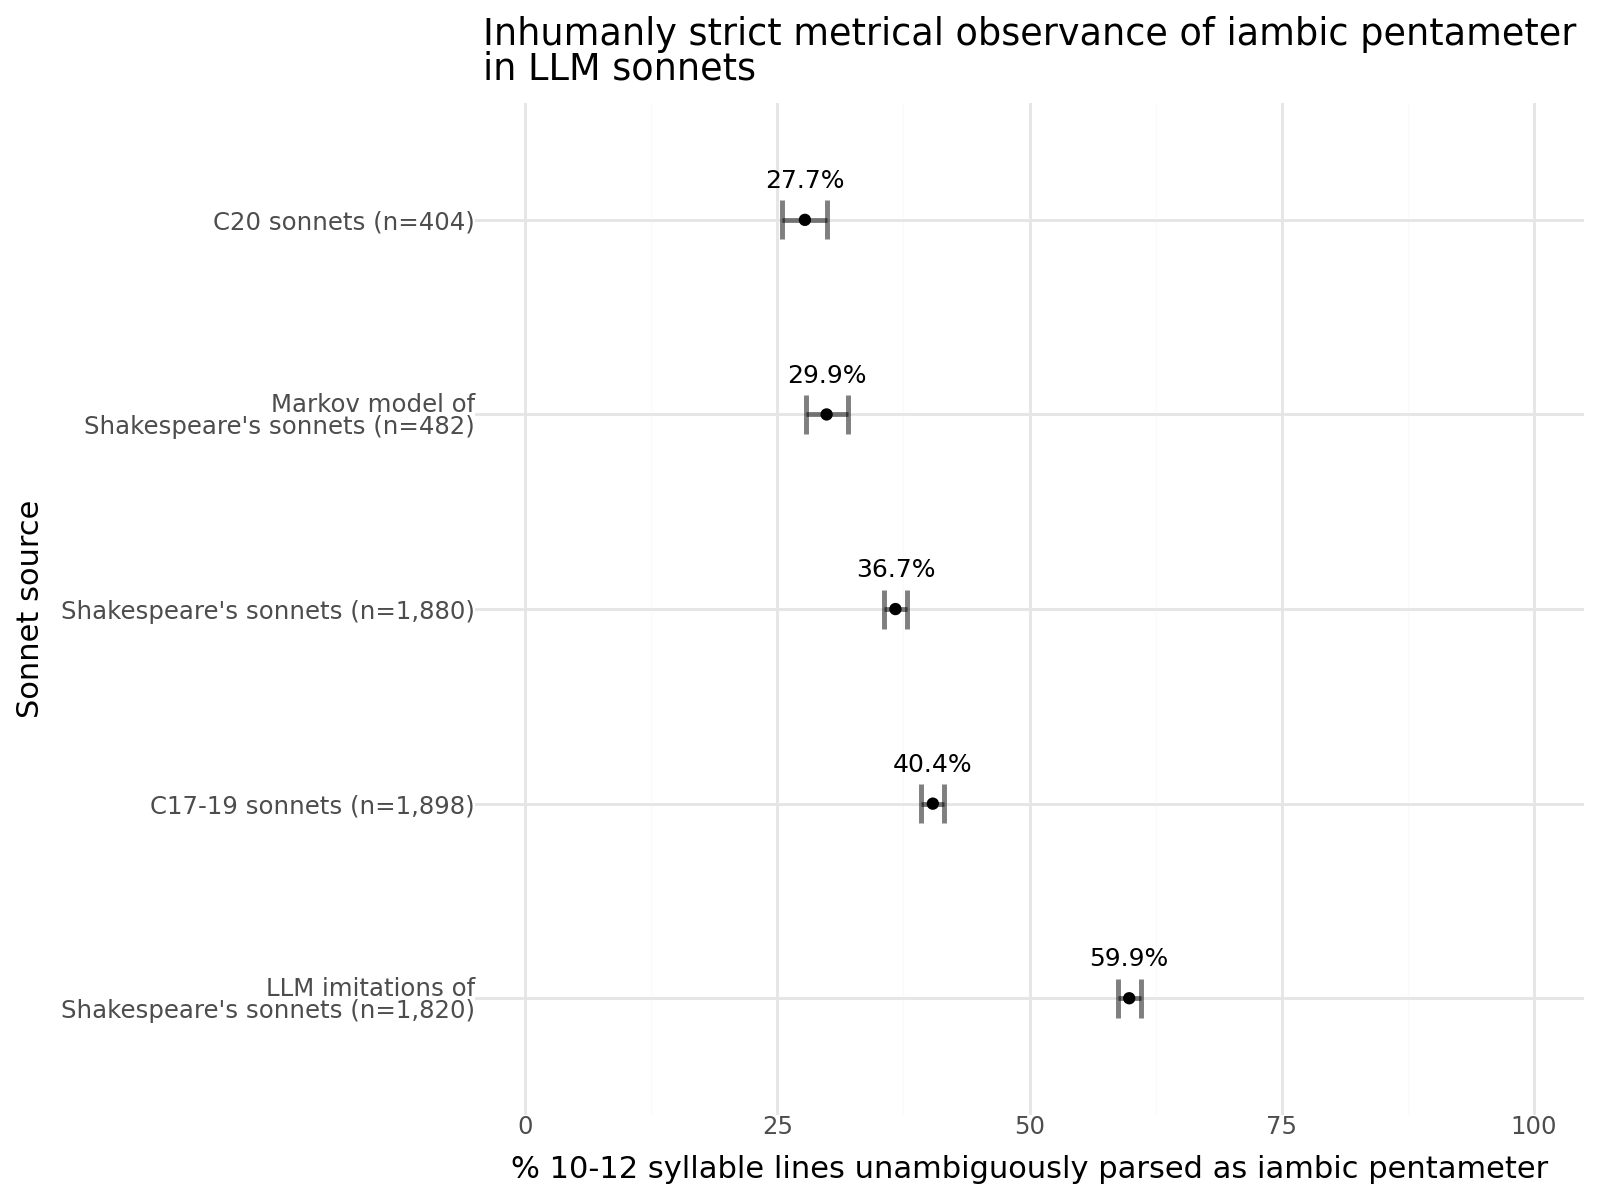

In [162]:
plot_trochaic_substitutions(metric='is_unambiguously_iambic_pentameter')

In [ ]:
dict(flex_parses_df.agent.value_counts())


In [156]:
import plotnine as p9
import numpy as np

def get_figdf_flex(parses_df):
    figdf = parses_df.reset_index()

    figdf['agent'] = figdf['model'].apply(get_agent)
    # figdf = figdf[~figdf['agent'].isin({'Markov2'})]

    figdf = pd.concat(
        gdf.assign(meter_syll_num=gdf.sort_values(['meterpos_num', 'meterslot_num']).groupby(['meterpos_num','meterslot_num']).ngroup() + 1)
        for g,gdf in figdf.groupby(['stanza_num','line_num','parse_meter','parse_rank'])
    )
    figdf = figdf.query('1 <= meter_syll_num <= 10')

    figdf['meter_prom'] = (figdf['meterpos_meter_val'] == 's').astype(int) * 100
    
    figdf = figdf.groupby(['meter_syll_num','agent']).agg({'meter_prom':['mean','std','count']}).reset_index()
    figdf.columns = ['meter_syll_num', 'agent', 'mean', 'std', 'count']

    p9.options.figure_size = (8, 6)
    figdf['label'] = figdf['mean'].apply(lambda x: f'{int(round(x*100))}%')
    figdf['meter_syll_num'] = pd.Categorical(figdf['meter_syll_num'].astype(int))
    
    figdf['value'] = figdf['mean']
    figdf['se'] = figdf['std'] / np.sqrt(figdf['count'])
    figdf['upper'] = figdf['mean'] + figdf['se']
    figdf['lower'] = figdf['mean'] - figdf['se']
    
    return figdf

figdf_melted_flex = get_figdf_flex(flex_parses_df)
figdf_melted_flex

,meter_syll_num,agent,mean,std,count,label,value,se,upper,lower
0,1,C17-19,21.657594,41.191676,36740,2166%,21.657594,0.214902,21.872496,21.442692
1,1,C20,28.054348,44.928919,9200,2805%,28.054348,0.468416,28.522764,27.585931
2,1,LLM,7.522568,26.379924,2991,752%,7.522568,0.482353,8.004921,7.040214
3,1,Markov,26.834738,44.311652,12931,2683%,26.834738,0.389674,27.224413,26.445064
4,1,Shakes,20.225487,40.174990,2927,2023%,20.225487,0.742582,20.968069,19.482905
...,...,...,...,...,...,...,...,...,...,...
45,10,C17-19,80.700296,39.466894,10824,8070%,80.700296,0.379349,81.079645,80.320947
46,10,C20,67.038069,47.018407,2154,6704%,67.038069,1.013083,68.051152,66.024986
47,10,LLM,91.293103,28.205770,1160,9129%,91.293103,0.828150,92.121253,90.464954
48,10,Markov,77.333333,41.883031,1350,7733%,77.333333,1.139912,78.473245,76.193422


In [157]:
def plot_figdf_flex(figdf=None):
    if figdf is None:
        figdf = get_figdf_flex(get_flex_parses_df())

    p9.options.figure_size = (9,7)

    figdf = figdf[~figdf['agent'].isin({'Markov2'})]
    fig = (p9.ggplot(figdf, 
                    p9.aes(x='meter_syll_num', 
                            y='mean',
                            color='agent',
                            )) + 
        p9.geom_line(p9.aes(group='agent'), size=.5, data=figdf, alpha=.5) +
    
        p9.geom_errorbar(p9.aes(ymin='lower', ymax='upper'), data=figdf, width=.35, size=.8, alpha=.5) +
        p9.geom_text(p9.aes(label='agent'),size=9, data=figdf.query('mean>0'), position=p9.position_nudge(x=.5)) +
        p9.geom_point(p9.aes(shape='agent'), data=figdf, alpha=.5) +
        p9.scale_size_continuous(range=[1,3]) +
        p9.theme_classic() +
    #        p9.facet_grid('violation_type~agent', scales='free_y') +
    #        p9.facet_wrap('agent', scales='free_y') +
        # p9.facet_wrap('violation_type', ncol=1, scales='free_y') +
        p9.scale_color_brewer(type='qual', palette='Set2') +
        p9.labs(x='Syllable Position', 
                y='Likelihood of metrical accent',
                fill='Violation Type',
                title='Likelihood of particular syllable in 10-syllable line being metrically accented'
                ))
    fig = fig + p9.theme(legend_position='bottom')
    fig.save('../../generative-humanities/Figures/MetricalAccentProbBySyll.png')
    return fig

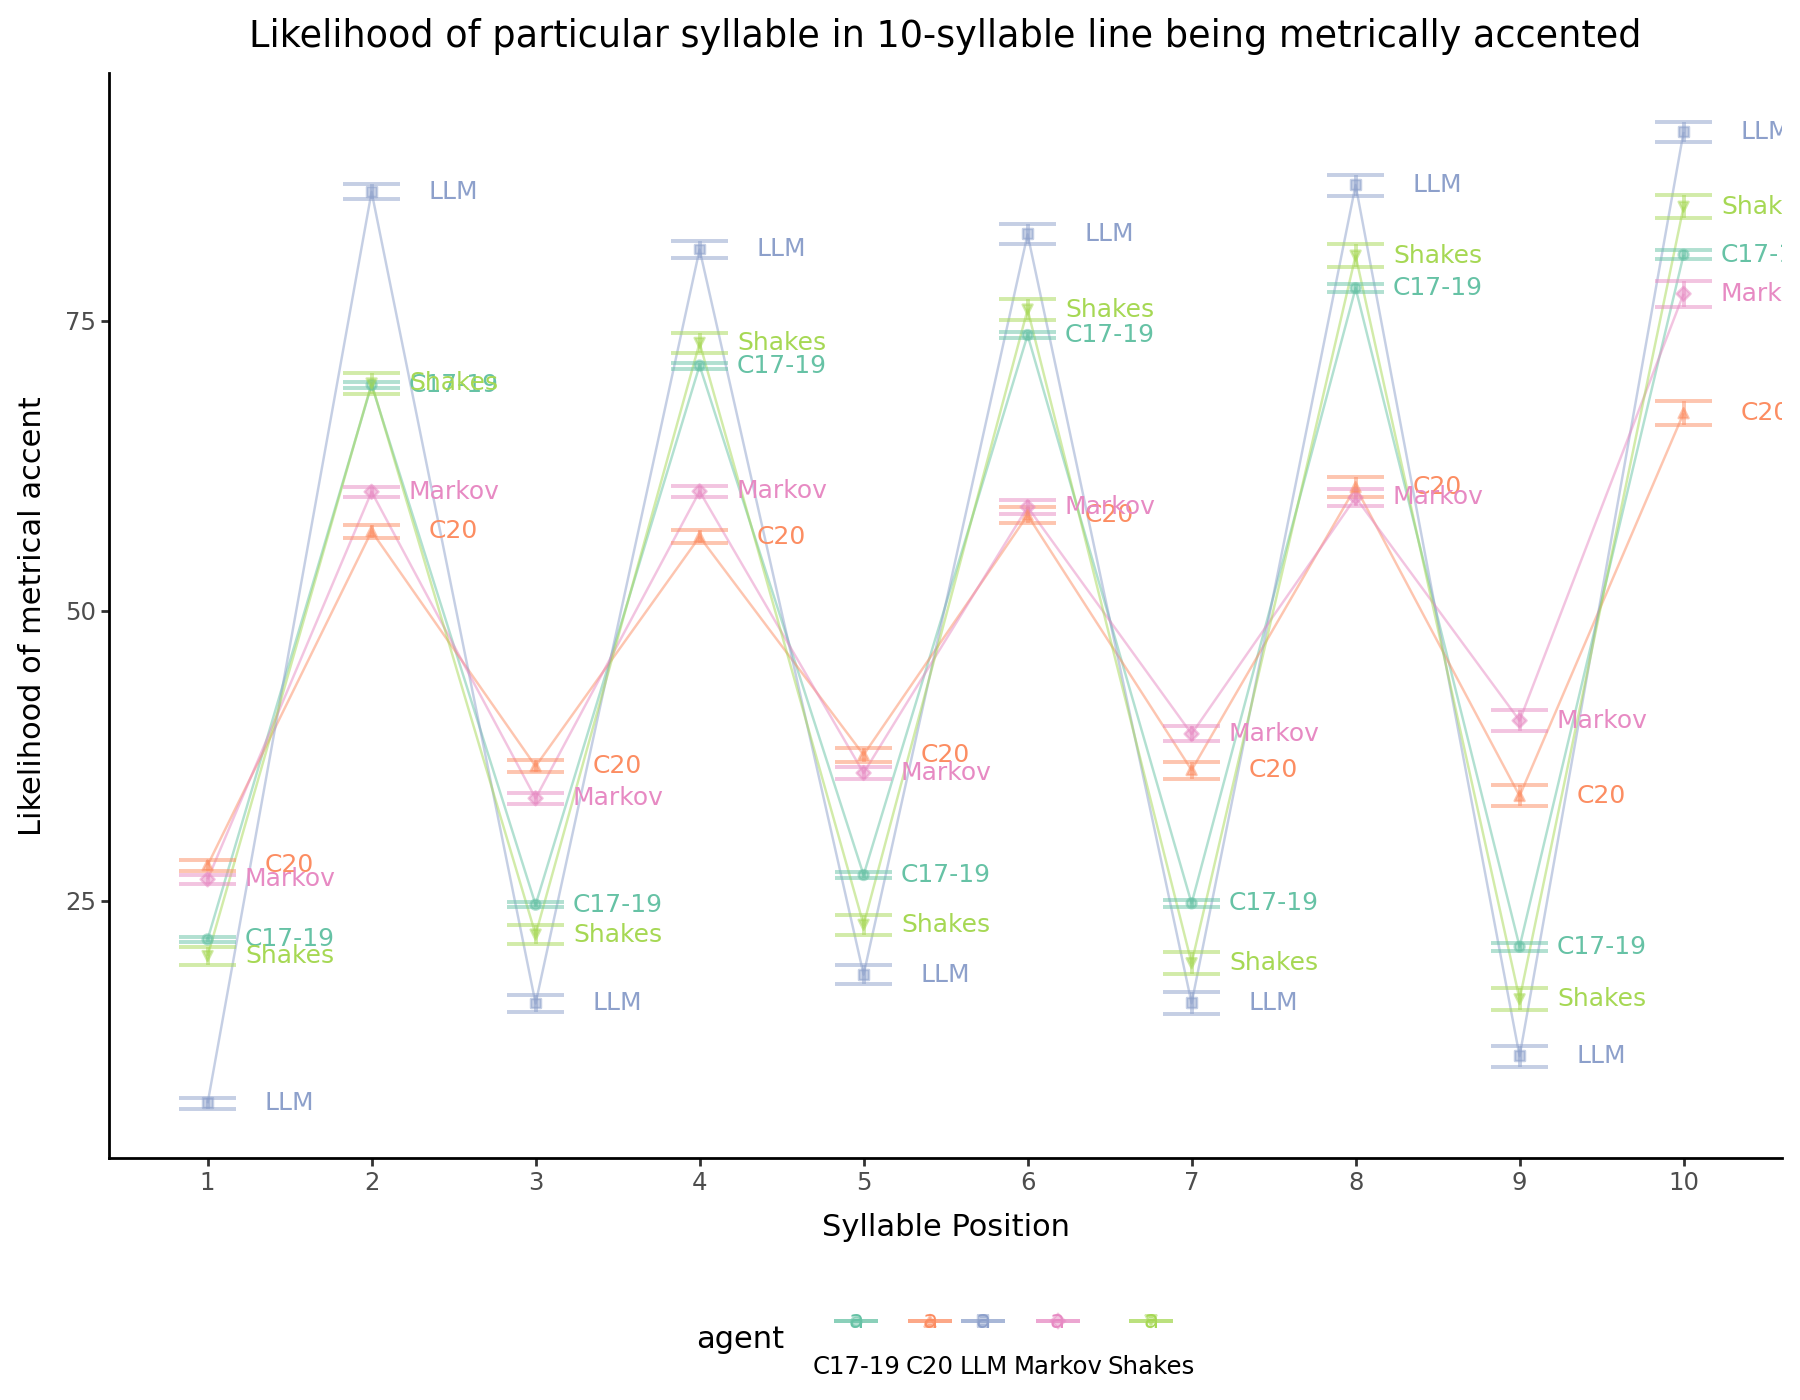

In [158]:
plot_figdf_flex()

['--', '+', '-', '+', '-', '+', '-', '+']

In [160]:
from collections import Counter

def get_figdf_flex_poems(parses_df=None):
    if parses_df is None:
        parses_df = get_flex_parses_df()
    ld=[]
    for g,gdf in parses_df.groupby('stanza_num'):
        parse_meters = ''.join(gdf.parse_meter)
        parse_meters_4thpos = gdf.parse_meter.apply(lambda x: int(x[3]=='+'))
        parse_meter_count = Counter(find_pos_in_meter_str(parse_meters))
        
        d = {'stanza_num':g, 'mpos_ww':parse_meter_count['--'] / parse_meter_count.total(), 'parse_meter_4thpos':parse_meters_4thpos.mean()
             }
        ld.append(d)
    figdf = pd.DataFrame(ld).merge(parses_df.reset_index().drop_duplicates('stanza_num'), on='stanza_num', how='left')
    return figdf

figdf_flex_poems = get_figdf_flex_poems(flex_parses_df)
figdf_flex_poems

IndexError: string index out of range

In [ ]:
def plot_hood_space(figdf=None):
    if figdf is None:
        figdf = get_figdf_flex_poems().copy()
    # figdf = figdf.query('mpos_ww < .25')
    # figdf = figdf.query('parse_meter_4thpos > .25')
    def get_agent_now(model):
        if model.startswith('b. '):
            return 'C17-C20'
            cents = int(model[3:5])+1
            if cents in {17,18}:
                return 'C17-18'
            return f'C{cents}'
        if model == 'shakespeare':
            return 'Shakespeare'
        else:
            return get_agent(model)
        


    figdf['agent'] = figdf['model'].apply(get_agent_now)
    figdf['agent'] = pd.Categorical(figdf['agent'], categories=['Shakespeare', 'C17-C20', 'Markov','LLM'], ordered=True)

    def get_model_category(model,agent):
        model = str(model)
        agent = str(agent)
        if agent.startswith('Markov'):
            return 'Markov'
            if 'shakespeare' in model.lower():
                return 'Markov (Shakespeare)'
            else:
                return 'Markov (C17-20)'
        elif model.startswith('b.'):
            cents = int(model[3:5])+1
            if cents in {17,18,19}:
                return 'C17-19'
            return f'C{cents}'
        else:
            return agent

    figdf['model_cat'] = figdf.apply(lambda row: get_model_category(row['model'],row['agent']), axis=1)
    print(figdf['model_cat'].value_counts())
    figdf['model_cat'] = pd.Categorical(figdf['model_cat'], categories=['Shakespeare', 'C17-19', 'C20', 'Markov', 'LLM'], ordered=True)

    figdf = figdf[~figdf['model_cat'].str.startswith('C')]
    figdf = figdf.groupby('model_cat').head(154)
    figdf['mpos_ww']*=100
    figdf['parse_meter_4thpos']*=100

    p9.options.figure_size = (9, 8)
    title='Upper left-hand is iambic meter'
    title+='\nThe further up, the more rising the meter'
    title+='\nThe further right, the more ternary the meter'
    fig = (
        p9.ggplot(figdf, p9.aes(x="mpos_ww", y="parse_meter_4thpos", color='model_cat', label='model_cat'))
        + p9.geom_point(size=1, alpha=.5)
        + p9.geom_density_2d(size=1.25, alpha=.8)
        + p9.geom_label(size=9, data=figdf.groupby(['agent','model_cat']).median(numeric_only=True).reset_index())
        # + p9.facet_wrap('agent',ncol=2)
        # + p9.facet_wrap('agent',nrow=1)
        + p9.theme_classic()
        + p9.theme(legend_position='none')
        + p9.scale_color_brewer(type='qual', palette='Set2')
        + p9.scale_x_continuous(limits=(0,25))
        + p9.scale_y_continuous(limits=(0,100))
        + p9.labs(y='% Lines rising', x='% Feet ternary', caption=title, title='Metrical Space')
    )
    fig.save('../../generative-humanities/Figures/HoodSpace.png')
    return fig


# figdf=plot_hood_space(figdf_flex_poems)
# figdf[['agent','model','model_cat']]
plot_hood_space()

In [32]:
import plotnine as p9

def get_figdf_iambic_pentameter(parses_df):
    figdf = parses_df.reset_index()

    figdf['agent'] = figdf['model'].apply(get_agent)
    figdf = figdf[~figdf['agent'].isin({'Markov2'})]

    figdf = pd.concat(
        gdf.assign(meter_syll_num=gdf.sort_values(['meterpos_num', 'meterslot_num']).groupby(['meterpos_num','meterslot_num']).ngroup() + 1)
        for g,gdf in figdf.groupby(['stanza_num','line_num','parse_meter','parse_rank'])
    )
    figdf = figdf.query('meter_syll_num <= 10')

    def get_line_num_type(line_num):
        if line_num in [1,2,3,4]:
            return 'Q1'
        elif line_num in [5,6,7,8]:
            return 'Q2'
        elif line_num in [9,10,11,12]:
            return 'Q3'
        elif line_num in [13,14]:
            return 'CC'

    figdf['line_num_type'] = figdf['line_num'].apply(get_line_num_type)

    # Get violation columns (those starting with *)
    viol_cols = [col for col in figdf.columns if col.startswith('*')]

    # Melt the DataFrame
    figdf_melted = pd.melt(
        figdf,
        id_vars=['meter_syll_num','line_num','agent'],
        value_vars=viol_cols,
        var_name='violation_type',
        value_name='violation_value'
    )
    figdf_melted['violation_value']*=100
    # Clean up violation_type names by removing the *
    figdf_melted['violation_type'] = figdf_melted['violation_type'].str.replace('*', '')

    p9.options.figure_size = (8, 6)
    figdf_melted['label'] = figdf_melted['violation_value'].apply(lambda x: f'{int(round(x*100))}%')

    violnames = {
        's_unstress': '*Lapse (Missing stress in strong position)',
        'w_stress': '*Clash (Unexpected stress in weak position)',
        'w_peak': '*Peak (Unexpected polysyllabic stress in weak position)',
        # 'unres_across': '*Unresolved across',
        # 'unres_within': '*Unresolved within',
    }

    figdf_melted['violation_type'] = figdf_melted['violation_type'].apply(lambda x: violnames.get(x, x))
    figdf_melted['meter_syll_num'] = pd.Categorical(figdf_melted['meter_syll_num'].astype(int))

    figdf_melted = figdf_melted[figdf_melted.violation_type.isin(set(violnames.values()))]
    figdf_melted['violation_type'] = pd.Categorical(figdf_melted['violation_type'], categories=list(violnames.values()))
    figdf_melted.agent.value_counts()

    return figdf_melted

figdf_melted = get_figdf_iambic_pentameter(flex_parses_df)

In [ ]:

import numpy as np
# Calculate mean and standard error for the line plot
line_data = (figdf_melted
             .groupby(['meter_syll_num','violation_type','agent'])
             .agg({
                 'violation_value': ['mean', 'std', 'count']
             })
             .reset_index())
line_data.columns = ['meter_syll_num', 'violation_type', 'agent', 'mean', 'std', 'count']
line_data['violation_value'] = line_data['mean']
line_data['se'] = line_data['std'] / np.sqrt(line_data['count'])
def safe_add(a, b):
    try:
        return a + b
    except TypeError:
        return float('nan')

def safe_subtract(a, b):
    try:
        return a - b
    except TypeError:
        return float('nan')

line_data['upper'] = line_data.apply(lambda row: safe_add(row['mean'], row['se']), axis=1)
line_data['lower'] = line_data.apply(lambda row: safe_subtract(row['mean'], row['se']), axis=1)
line_data['group'] = line_data['agent'].astype(str)# + '_' + line_data['violation_type'].astype(str)
line_data = line_data.query('mean>0')
line_data = line_data.sort_values(['group','meter_syll_num'])
line_data

In [ ]:
figdf_now = figdf_melted#.query('label != "0%"')
# line_data['line_count'] = line_data['count'] / 14


p9.options.figure_size = (10, 10)

fig = (p9.ggplot(figdf_now, 
                 p9.aes(x='meter_syll_num', 
                        y='violation_value',
                        color='agent')) + 
       p9.geom_line(p9.aes(group='agent'), size=.5, data=line_data, alpha=.5) +
 
       p9.geom_errorbar(p9.aes(ymin='lower', ymax='upper'), data=line_data, width=.35, size=.8, alpha=.5) +
       p9.geom_text(p9.aes(label='agent'),size=8, data=line_data.query('mean>0'), position=p9.position_nudge(x=.25)) +
       p9.geom_point(p9.aes(shape='agent'), data=line_data, alpha=.5) +
       p9.scale_size_continuous(range=[1,3]) +
       p9.theme_classic() +
#        p9.facet_grid('violation_type~agent', scales='free_y') +
#        p9.facet_wrap('agent', scales='free_y') +
       p9.facet_wrap('violation_type', ncol=1, scales='free_y') +
       p9.scale_color_brewer(type='qual', palette='Set1') +
       p9.labs(x='Syllable Position', 
               y='Violation Rate',
               fill='Violation Type',
               title='Metrical rule violations to iambic pentameter by syllable'
               ))
fig = fig + p9.theme(legend_position='bottom')
fig.save('../../generative-humanities/Figures/ViolsBySyll.png')
fig